# Homework 10: Regression Inference

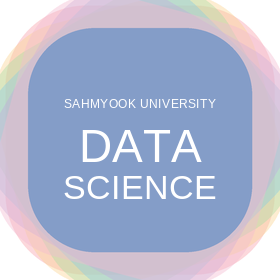

**Helpful Resource:**

- [Python Reference](http://data8.org/sp26/reference/): Cheat sheet of helpful array & table methods used in this data science course!

**Recommended Reading**: 

* [Using Confidence Intervals](https://inferentialthinking.com/chapters/13/4/Using_Confidence_Intervals.html)
* [The Regression Line](https://inferentialthinking.com/chapters/15/2/Regression_Line.html#the-regression-line-in-standard-units)
* [Inference for Regression](https://www.inferentialthinking.com/chapters/16/Inference_for_Regression.html)

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw10')
os.makedirs('tests', exist_ok=True)
with open('hw10.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw10.ipynb')
print('Ready! (13 tests loaded)')

Please complete this notebook by filling in the cells provided. **Before you begin, execute the cell below to setup the notebook by importing some helpful libraries.** Each time you start your server, you will need to execute this cell again.

Throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

---

The point breakdown for this assignment is given in the table below:
| Category | Points |
| --- | --- |
| Autograder (Coding questions) | 78 |
| Written (1.4, 2.4) | 16 |
| **Total** | 94 |

In [ ]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *

# These lines do some fancy plotting magic
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore')
from datetime import datetime

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## An Introduction to Regression Inference

Previously in this class, we've used confidence intervals to quantify uncertainty about estimates. We can also run hypothesis tests using a confidence interval under the following procedure:

1. Define a null and alternative hypothesis (they must be of the form "The parameter is X" and "The parameter is not X").
2. Choose a p-value cutoff, and call it $q$, where $q$ is a percentage.
3. Construct a $(100\%-q)\%$ confidence interval using bootstrap sampling (for example, if your p-value cutoff is 1%, or 0.01, then construct a 99% confidence interval).
4. Using the confidence interval, determine if your data are more consistent with your null or alternative hypothesis, at your $q\%$ p-value cutoff:
   * If the null hypothesis parameter X is in your confidence interval, the data are more consistent with the null hypothesis.
   * If the null hypothesis parameter X is *not* in your confidence interval, the data are more consistent with the alternative hypothesis.

More recently, we've discussed the use of linear regression to make predictions based on correlated variables. For example, we can predict the height of children based on the heights of their parents.

We can combine these two topics to make powerful statements about our population by using the following techniques:

- Bootstrapped interval for the true slope
- Bootstrapped prediction interval for y (given a particular value of x)

This homework explores these two methods.

---

## The Data
The [Snowy Plover](https://www.audubon.org/field-guide/bird/snowy-plover) is a tiny bird that lives on the coast in parts of California and elsewhere. It is so small that it is vulnerable to many predators, including people and dogs that don't look where they are stepping when they go to the beach. It is considered endangered in many parts of the U.S.

The data are about the eggs and newly-hatched chicks of the Snowy Plover. Here's a picture of a parent bird incubating its eggs.

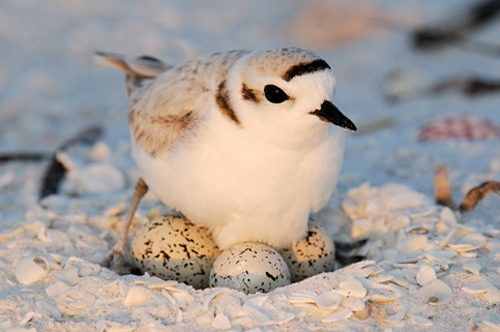

The data were collected at the Point Reyes National Seashore by a former [student at Berkeley](https://openlibrary.org/books/OL2038693M/BLSS_the_Berkeley_interactive_statistical_system). The goal was to see how the size of an egg could be used to predict the weight of the resulting chick. The bigger the newly-hatched chick, the more likely it is to survive.

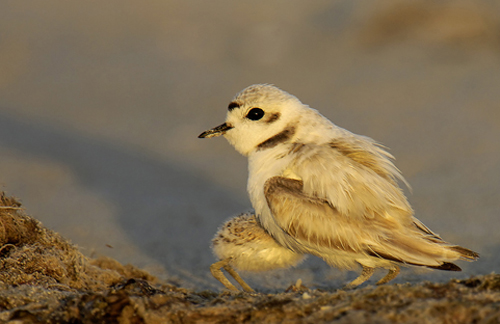

Each row of the table below corresponds to one Snowy Plover egg and the resulting chick. Note how tiny the bird is:

- `Egg Length` and `Egg Breadth` (widest diameter) are measured in millimeters
- `Egg Weight` and `Bird Weight` are measured in grams; for comparison, a standard paper clip weighs about one gram

In [ ]:
birds = Table.read_table('snowy_plover.csv')
birds

In this investigation, we will be using the egg weight to predict bird weight. Run the cell below to create a scatter plot of the egg weights and bird weights, along with their line of best fit.

In [ ]:
# Just run this cell and examine the scatter plot.
birds.scatter('Egg Weight', "Bird Weight", fit_line=True)

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Finding the Bootstrap Confidence Interval for the True Slope

Looking at the scatter plot of our sample, we observe a linear relationship between egg weight and bird weight. However, relationships that we have identified in the sample might not be representative of the true relationship in the population.

We want to know if there truly exists a linear relationship between egg weight and bird weight for Snowy Plovers. If there is no linear relationship between the two variables, then we'd expect a correlation of 0. Consequently, the slope of the regression line would also be 0. 

We highly recommend reviewing section [16.2](https://inferentialthinking.com/chapters/16/2/Inference_for_the_True_Slope.html) before attempting this part of the homework

---

**Question 1.1.** Let's run a hypothesis test using confidence intervals to see if there is a linear relationship between egg weight and bird weight.
Choose the appropriate null and alternative hypotheses that will allow you to conduct this test. Assign the numbers corresponding to the correct null and alternative hypotheses to `null_hypothesis` and `alt_hypothesis`. **(12 points)**

1. The true slope of the regression line, computed using our sample of Snowy Plovers, is 0.

2. The true slope of the regression line, computed using our sample of Snowy Plovers, is not 0.

2. The true slope of the regression line, computed using our sample of Snowy Plovers, is greater than 0.

3. The true slope of the regression line, computed using the population of all Snowy Plovers, is 0.

4. The true slope of the regression line, computed using the population of all Snowy Plovers, is not 0.

2. The true slope of the regression line, computed using the population of Snowy Plovers, is greater than 0.

*Hint:* Our regression line predicts bird weight from egg weight!

In [ ]:
null_hypothesis = ...
alt_hypothesis =  ...

In [ ]:
grader.check("q1_1")

---

**Question 1.2.** Define the following two functions:

1. `standard_units`: This function takes in an array of numbers and returns an array containing those numbers converted to standard units.
2. `correlation`: This function takes in a table and two column names (one for *x* and one for *y*) and returns the correlation between these columns. 

**(4 points)**


In [ ]:
def standard_units(arr):
    ...

def correlation(tbl, x_col, y_col):
    ...

In [ ]:
grader.check("q1_2")

---

**Question 1.3.** Using the functions you just implemented, create a function called `fit_line`.  It should take a table (e.g. `birds`) and the column names associated to *x* and *y* as its arguments and return an *array* containing the slope and intercept of the regression line (in that order) that predicts the *y* column in the table using the *x* column. **(8 points)**


In [ ]:
def fit_line(tbl, x_col, y_col):
    ...

fit_line(birds, "Egg Weight", "Bird Weight")

In [ ]:
grader.check("q1_3")

**Run** this cell to plot the line produced by calling `fit_line` on the `birds` table.  

**Note:** You are not responsible for the code in the cell below, but make sure that your `fit_line` function generated a reasonable line for the data.

In [ ]:
# Ensure your fit_line function fits a reasonable line 
# to the data in birds, using the plot below.

# Just run this cell
sample_slope, sample_intercept = fit_line(birds, "Egg Weight", "Bird Weight")
birds.scatter("Egg Weight", "Bird Weight")
plt.plot([min(birds.column("Egg Weight")), max(birds.column("Egg Weight"))], 
         [sample_slope*min(birds.column("Egg Weight"))+sample_intercept, sample_slope*max(birds.column("Egg Weight"))+sample_intercept])
plt.show()

Now we have all the tools we need to create a confidence interval that quantifies our uncertainty about the true relationship between egg weight and bird weight.

<!-- BEGIN QUESTION -->

---

**Question 1.4.** Create an array called `resampled_slopes` that contains the slope of the best fit line for 1000 bootstrap resamples of `birds`. Plot the distribution of these slopes. **(8 points)**

*Hint:* Use the `fit_line` function you defined in 1.3.

In [ ]:
resampled_slopes = ...

for i in np.arange(1000): 
    birds_bootstrap = ...
    bootstrap_line = ...
    bootstrap_slope = ...
    resampled_slopes = ...
    
# DO NOT CHANGE THIS LINE
Table().with_column("Slope estimate", resampled_slopes).hist()

In [ ]:
grader.check("q1_4")

<!-- END QUESTION -->

---

**Question 1.5.** Use your resampled slopes to construct an 95% confidence interval for the true value of the slope. **(8 points)**

In [ ]:
lower_end = ...
upper_end = ...
print("95% confidence interval for slope: [{:g}, {:g}]".format(lower_end, upper_end))

In [ ]:
grader.check("q1_5")

---

**Question 1.6.** Based on your confidence interval, would you reject or fail to reject the null hypothesis that the true slope is 0?  Why?  What p-value cutoff are you using?

Select all statements that are correct given your 95% confidence interval from the previous question, and assign your answers to the array `ci_conclusion`. **(10 points)**

1. Because 0 is outside of our 95% confidence interval, there is evidence that the true slope is non-zero.

2. Because 0 is outside of our 95% confidence interval, there is evidence the true slope is zero.

3. We are using a p-value cutoff of 0.05.

4. We are using a p-value cutoff of 0.95.

5. Based on our confidence interval and p-value cutoff, we would fail to reject the null hypothesis.

6. Based on our confidence interval and p-value cutoff, we would reject the null hypothesis.

*Hint*: Read the introduction of this homework!

In [ ]:
ci_conclusion = make_array(...)

In [ ]:
grader.check("q1_6")

---

**Question 1.7.** Assume that the 95% confidence interval you generated in Question 1.5 was $[0.6, 0.8]$.

Select all statements that are correct interpretations of this interval, and assign your answers to the array `confidence_interval_uses`. **(8 points)**

1. This interval allows us to make a conclusion about whether the true slope is 0, at a 5% p-value cutoff.

2. There is a 95% chance that the true slope falls between $[0.6, 0.8]$.

3. We are 95% confident that the true slope is somewhere between $[0.6, 0.8]$.

In [ ]:
confidence_interval_uses = make_array(...)

In [ ]:
grader.check("q1_7")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. Finding the Bootstrap Prediction Interval

Suppose we're visiting Point Reyes and stumble upon some Snowy Plover eggs; we'd like to know how heavy they'll be once they hatch. In other words, we want to use our regression line to make predictions about a bird's weight based on the weight of the corresponding egg.

However, just as we're uncertain about the slope of the true regression line, we're also uncertain about the predictions made based on the true regression line.

---

**Question 2.1.** Define the function `fitted_value`.  It should take in four arguments:

1. `table`: a table like `birds`.  We'll be predicting the values in the second column using the first.
2. `x_col`: the name of our x-column within the input `table`
3. `y_col`: the name of our y-column within the input `table`
2. `given_x`: a number, the value of the predictor variable for which we'd like to make a prediction.
  
The function should return the line’s prediction for the given x. **(6 points)**

*Hint:* Make sure to use the `fit_line` function you defined in Question 1.3.


In [ ]:
def fitted_value(table, x_col, y_col, given_x):
    line = ...
    slope = ...
    intercept = ...
    ...

# Here's an example of how fitted_value is used. The code below
# computes the prediction for the bird weight, in grams, based on
# an egg weight of 8 grams.
egg_weight_eight = fitted_value(birds, "Egg Weight", "Bird Weight", 8)
egg_weight_eight

In [ ]:
grader.check("q2_1")

---

**Question 2.2.** Raymond, the resident Snowy Plover expert at Point Reyes, tells us that the egg he has been carefully observing has a weight of 9 grams. Using `fitted_value` above, assign the variable `experts_egg` as the predicted bird weight for Raymond's egg. **(4 points)**


In [ ]:
experts_egg = ...
experts_egg

In [ ]:
grader.check("q2_2")

In [ ]:
# Let's look at the number of rows in the birds table.
birds.num_rows

A fellow parkgoer raises the following objection to your prediction:

> "Your prediction depends on your sample of 44 birds.  Wouldn't your prediction change if you had a different sample of 44 birds?"

Having read section [16.3](https://inferentialthinking.com/chapters/16/3/Prediction_Intervals.html) of the textbook, you know just the response! Had the sample been different, the regression line would have been different too. This would ultimately result in a different prediction. To see how good our prediction is, we must get a sense of how variable the prediction can be.

---

**Question 2.3.** Define a function `compute_resampled_line` that takes in a table `tbl`and two column names, `x_col` and `y_col`, and returns an array containing the parameters of the best fit line (slope and intercept) for one bootstrapped resample of the table. **(6 points)**


In [ ]:
def compute_resampled_line(tbl, x_col, y_col):
    resample = ...
    resampled_line = ...
    ...

In [ ]:
grader.check("q2_3")

**Run** the following cell below in order to define the function `bootstrap_lines`.  It takes in four arguments:
1. `tbl`: a table like `birds`
2. `x_col`: the name of our x-column within the input `tbl`
3. `y_col`: the name of our y-column within the input `tbl`
4. `num_bootstraps`: an integer, a number of bootstraps to run.

It returns a *table* with one row for each bootstrap resample and the following two columns:
1. `Slope`: the bootstrapped slopes 
2. `Intercept`: the corresponding bootstrapped intercepts 

In [ ]:
# Just run this cell
def bootstrap_lines(tbl, x_col, y_col, num_bootstraps):
    resampled_slopes = make_array()
    resampled_intercepts = make_array() 
    for i in np.arange(num_bootstraps): 
        resampled_line = compute_resampled_line(tbl, x_col, y_col) 
        resampled_slope = resampled_line.item(0) 
        resampled_intercept = resampled_line.item(1) 
        resampled_slopes = np.append(resampled_slopes,resampled_slope)
        resampled_intercepts = np.append(resampled_intercepts,resampled_intercept)
    tbl_lines = Table().with_columns('Slope', resampled_slopes, 'Intercept', resampled_intercepts)
    return tbl_lines

regression_lines = bootstrap_lines(birds, "Egg Weight", "Bird Weight", 1000)
regression_lines

<!-- BEGIN QUESTION -->

---

**Question 2.4.** Create an array called `predictions_for_eight` that contains the predicted bird weights based on an egg of weight 8 grams for each regression line in `regression_lines`. **(8 points)**

In [ ]:
predictions_for_eight = ...

# This will make a histogram of your predictions:
table_of_predictions = Table().with_column('Predictions at Egg Weight=8', predictions_for_eight)
table_of_predictions.hist('Predictions at Egg Weight=8', bins=20)

In [ ]:
grader.check("q2_4")

<!-- END QUESTION -->

---

**Question 2.5.** Create an approximate 95% confidence interval for these predictions. **(6 points)**

In [ ]:
lower_bound = ...
upper_bound = ...

print('95% Confidence interval for predictions for x=8: (', lower_bound,",", upper_bound, ')')

In [ ]:
grader.check("q2_5")

---

**Question 2.6.** Set `plover_statements` to an array of integer(s) that correspond to statement(s) that are true. **(6 points)**

1. The 95% confidence interval covers 95% of the bird weights for eggs that had a weight of eight grams in `birds`.

2. The 95% confidence interval gives a sense of how much actual weights differ from your prediction.

3. The 95% confidence interval quantifies the uncertainty in our estimate of what the true line would predict.

In [ ]:
plover_statements = ...

In [ ]:
grader.check("q2_6")

You're all done with Homework 10!

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


## Pets of this data science course

Fluffy hopes you have a wonderful rest of your week!

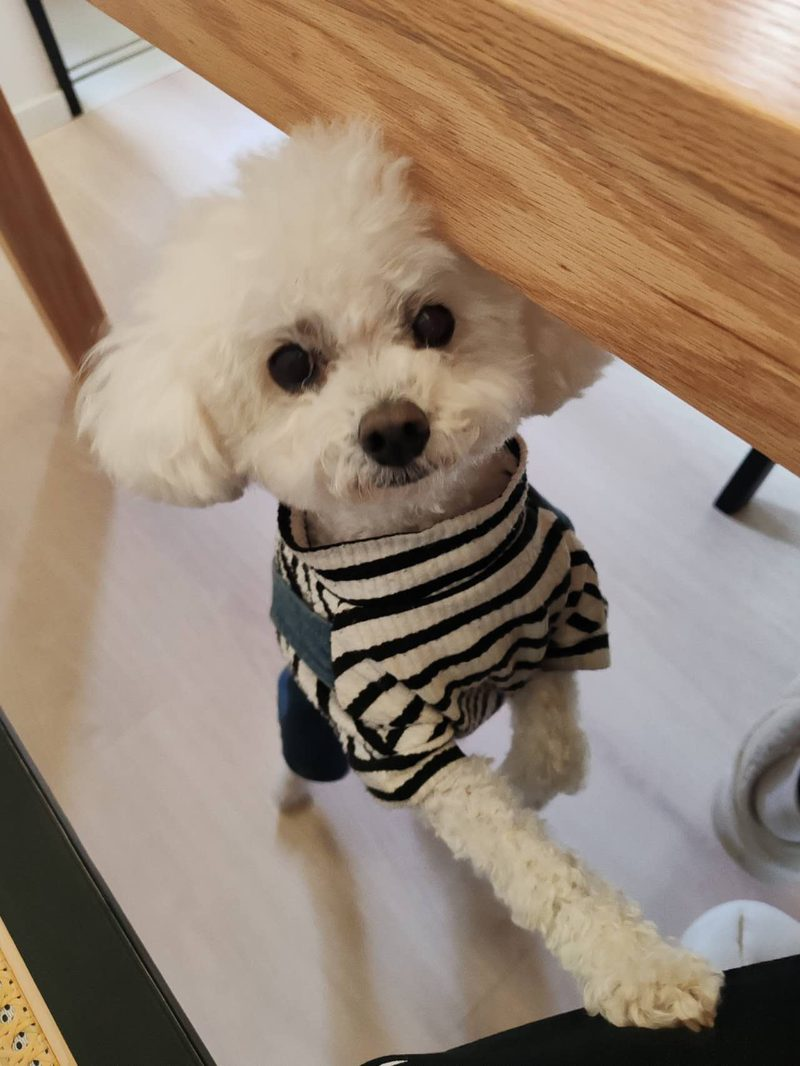

Congrats on finishing Homework 10!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_